In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales_dataset (1).csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales_dataset (1).csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1000, 9)

Column Names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data Types:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [4]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [5]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

print(category_sales)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


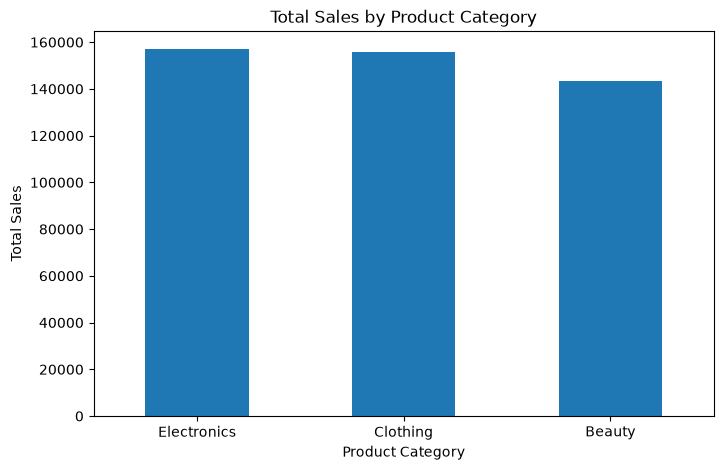

In [6]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()


In [7]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

print(gender_sales)

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


In [8]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Amount'].sum()

print(monthly_sales)

AttributeError: Can only use .dt accessor with datetimelike values

In [9]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print(df['Date'].dtype)

datetime64[us]


In [10]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Amount'].sum()

print(monthly_sales)

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


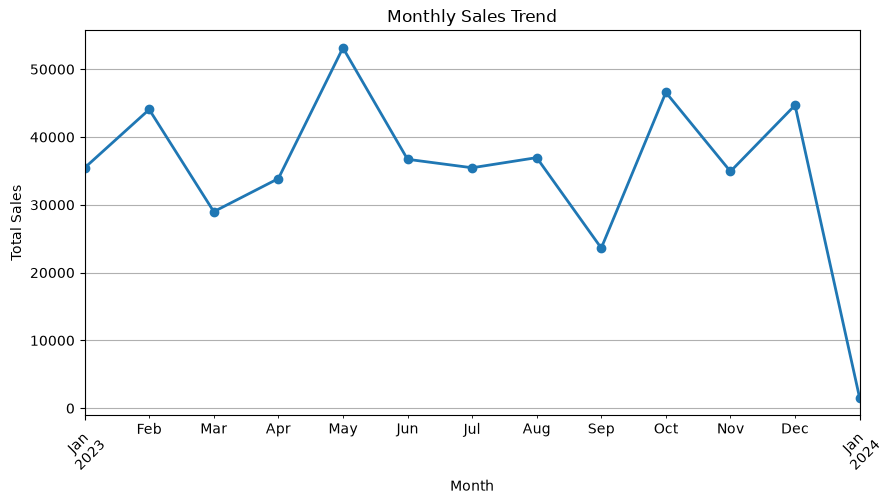

In [11]:
plt.figure(figsize=(10,5))

monthly_sales.plot(kind='line', marker='o', linewidth=2)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

In [12]:
age_sales = df.groupby('Age')['Total Amount'].sum().sort_values(ascending=False)

print(age_sales.head(10))


Age
43    17970
34    16785
51    16065
19    14870
26    13980
22    13700
46    13090
21    12585
47    12505
37    11650
Name: Total Amount, dtype: int64


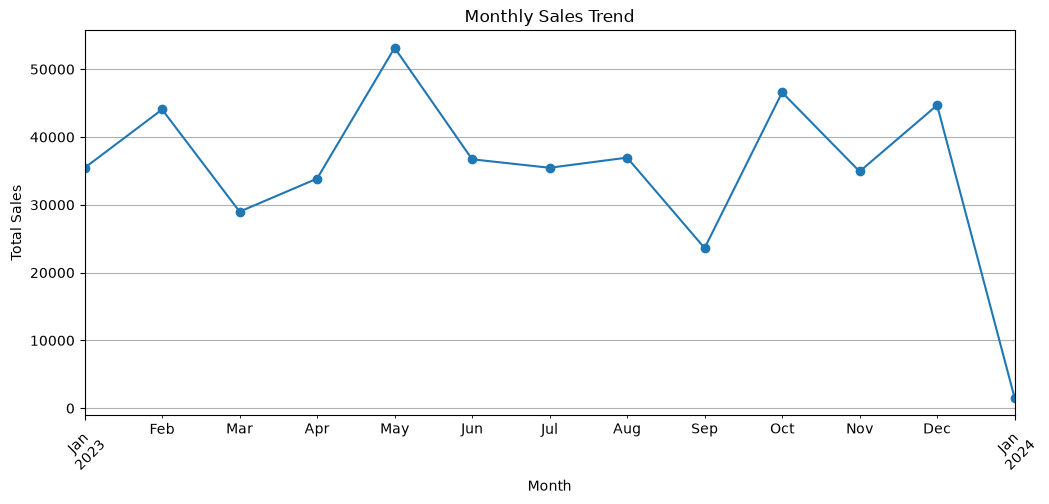

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

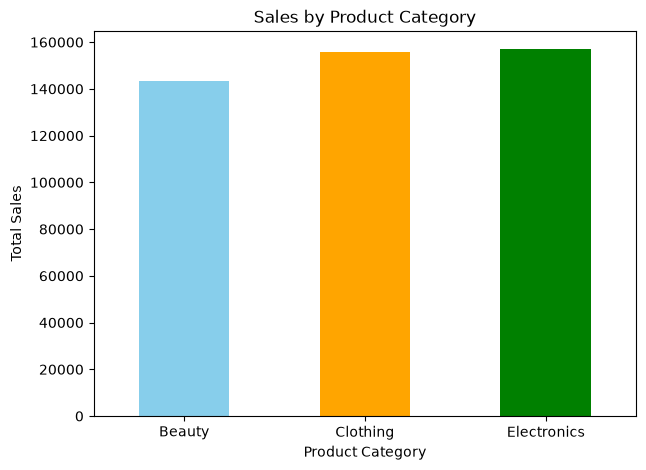

In [14]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

plt.figure(figsize=(7,5))
category_sales.plot(kind='bar', color=['skyblue','orange','green'])
plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

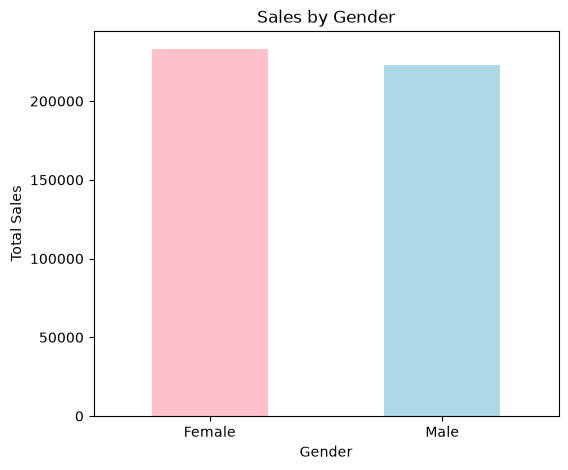

In [15]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

plt.figure(figsize=(6,5))
gender_sales.plot(kind='bar', color=['pink','lightblue'])
plt.title('Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

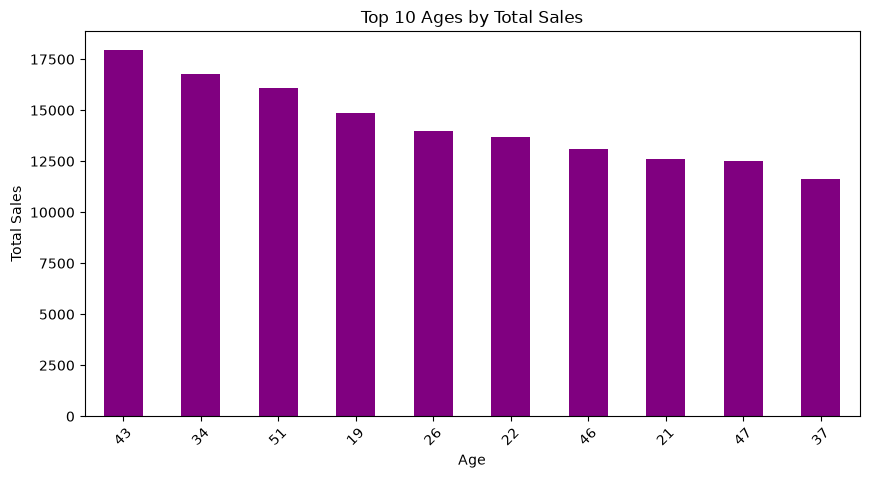

In [16]:
age_sales = df.groupby('Age')['Total Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
age_sales.plot(kind='bar', color='purple')
plt.title('Top 10 Ages by Total Sales')
plt.xlabel('Age')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

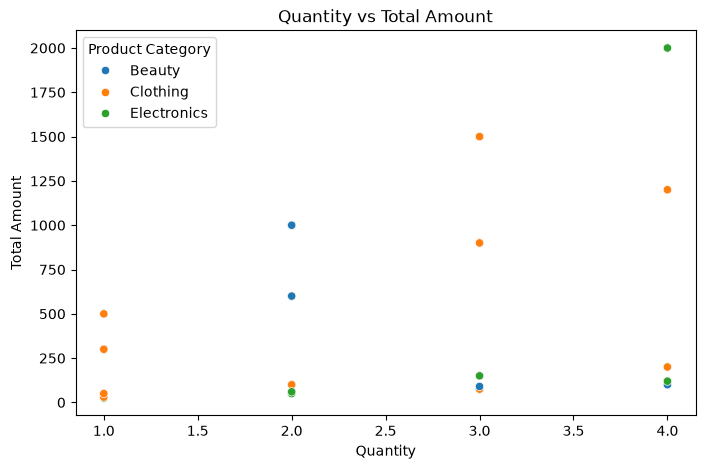

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Quantity', y='Total Amount', hue='Product Category')
plt.title('Quantity vs Total Amount')
plt.show()

In [18]:
print("===== KEY INSIGHTS =====")

print("\n1. Total Sales:")
print(df['Total Amount'].sum())

print("\n2. Total Transactions:")
print(df['Transaction ID'].nunique())

print("\n3. Best Product Category:")
print(category_sales.idxmax(), "-", category_sales.max())

print("\n4. Best Gender:")
print(gender_sales.idxmax(), "-", gender_sales.max())

print("\n5. Best Sales Month:")
print(monthly_sales.idxmax(), "-", monthly_sales.max())

print("\n6. Best Age Group:")
print(age_sales.idxmax(), "-", age_sales.max())

===== KEY INSIGHTS =====

1. Total Sales:
456000

2. Total Transactions:
1000

3. Best Product Category:
Electronics - 156905

4. Best Gender:
Female - 232840

5. Best Sales Month:
2023-05 - 53150

6. Best Age Group:
43 - 17970


In [19]:
print("""
CONCLUSION

1. The dataset contains 1,000 retail transactions.
2. Total sales generated were ₹456,000.
3. Electronics was the highest-performing product category with ₹156,905 in sales.
4. Female customers contributed higher sales of ₹232,840 compared to male customers.
5. May 2023 recorded the highest monthly sales of ₹53,150.
6. Customers aged 43 generated the highest sales among individual age groups, with ₹17,970.
7. The analysis shows that product category, customer gender, age, and month have useful patterns that can help understand retail sales performance.
""")


CONCLUSION

1. The dataset contains 1,000 retail transactions.
2. Total sales generated were ₹456,000.
3. Electronics was the highest-performing product category with ₹156,905 in sales.
4. Female customers contributed higher sales of ₹232,840 compared to male customers.
5. May 2023 recorded the highest monthly sales of ₹53,150.
6. Customers aged 43 generated the highest sales among individual age groups, with ₹17,970.
7. The analysis shows that product category, customer gender, age, and month have useful patterns that can help understand retail sales performance.

